Используем предобученную модель

In [1]:
from ultralytics import YOLO
import cv2
import torch
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
model = YOLO("yolov8n.pt")

WARNING torchvision==0.20 is incompatible with torch==2.6.
Run 'pip install torchvision==0.21' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation


In [2]:
# Проверка на работоспособность CUDA
print(torch.__version__)  # Версия PyTorch
print(torch.cuda.is_available())  # Доступна ли CUDA?
print(torch.version.cuda)  # Версия CUDA, с которой собран PyTorch

2.6.0.dev20241112+cu121
True
12.1


Делаем предсказание по изображению


0: 448x640 3 cars, 1 truck, 1 stop sign, 58.5ms
Speed: 4.4ms preprocess, 58.5ms inference, 117.9ms postprocess per image at shape (1, 3, 448, 640)


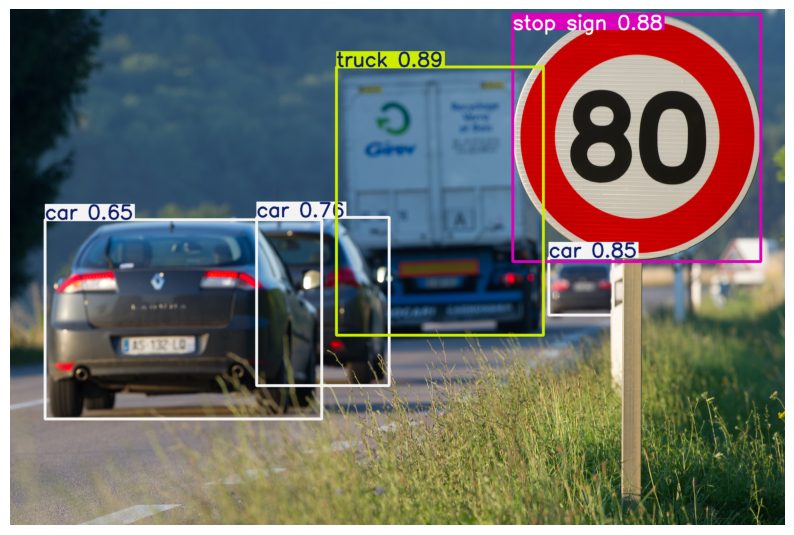

In [3]:
def predict_and_show(image_path, model_path="yolov8n.pt"):
    """
    Функция для предсказания объектов на изображении с помощью YOLO и визуализации результатов в Jupyter Notebook
    
    Аргументы:
        image_path (str): Путь к файлу изображения
        model_path (str): Путь к файлу весов модели YOLO (по умолчанию "yolov8n.pt")
    """
    # Загрузка модели (принудительно на CPU, если CUDA не работает)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = YOLO(model_path).to(device)
    
    # Чтение изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: не удалось загрузить изображение по пути {image_path}")
        return
    
    # Предсказание
    results = model.predict(image)
    
    # Визуализация результатов
    annotated_image = results[0].plot()
    
    # Конвертация из BGR (OpenCV) в RGB (matplotlib)
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    
    # Вывод изображения с помощью matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image_rgb)
    plt.axis('off')  # Скрыть оси
    plt.show()
    
predict_and_show("images/lxjh2x6rv0finbsjv17qmu7hi1hsr1jv.jpeg")

Выводим детальную информацию по изображению

In [4]:
def predict_and_describe(image_path, model_path="yolov8n.pt", conf_threshold=0.5):
    """
    Функция для предсказания объектов на изображении с помощью YOLO и вывода детальной информации в консоль
    
    Аргументы:
        image_path (str): Путь к файлу изображения
        model_path (str): Путь к файлу весов модели YOLO
        conf_threshold (float): Порог уверенности для отображения объектов (по умолчанию 0.5)
    """
    # Загрузка модели
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = YOLO(model_path).to(device)
    
    # Чтение изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: не удалось загрузить изображение по пути {image_path}")
        return
    
    # Предсказание
    results = model.predict(image)
    
    # Получаем первый результат (если изображение одно)
    result = results[0]
    
    # Выводим заголовок
    print("\nРезультаты обнаружения объектов:")
    print("-" * 60)
    
    # Перебираем все обнаруженные объекты
    for i, box in enumerate(result.boxes):
        # Получаем класс объекта
        class_id = int(box.cls)
        class_name = result.names[class_id]
        
        # Получаем координаты bounding box (xyxy формат)
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        # Получаем уверенность предсказания
        confidence = float(box.conf)
        
        # Пропускаем объекты с низкой уверенностью
        if confidence < conf_threshold:
            continue
        
        # Выводим информацию об объекте
        print(f"Объект #{i+1}:")
        print(f"  Класс: {class_name} ({class_id})")
        print(f"  Координаты: [({x1:.2f}, {y1:.2f}), ({x2:.2f}, {y2:.2f})]")
        print(f"  Уверенность: {confidence:.4f}")
        print("-" * 60)
    

predict_and_describe("images/lxjh2x6rv0finbsjv17qmu7hi1hsr1jv.jpeg")


0: 448x640 3 cars, 1 truck, 1 stop sign, 9.7ms
Speed: 1.8ms preprocess, 9.7ms inference, 2.1ms postprocess per image at shape (1, 3, 448, 640)

Результаты обнаружения объектов:
------------------------------------------------------------
Объект #1:
  Класс: truck (7)
  Координаты: [(842.99, 149.48), (1376.70, 841.30)]
  Уверенность: 0.8899
------------------------------------------------------------
Объект #2:
  Класс: stop sign (11)
  Координаты: [(1297.22, 13.75), (1937.06, 651.76)]
  Уверенность: 0.8796
------------------------------------------------------------
Объект #3:
  Класс: car (2)
  Координаты: [(1390.80, 641.28), (1556.68, 789.70)]
  Уверенность: 0.8484
------------------------------------------------------------
Объект #4:
  Класс: car (2)
  Координаты: [(636.66, 537.77), (978.84, 971.19)]
  Уверенность: 0.7566
------------------------------------------------------------
Объект #5:
  Класс: car (2)
  Координаты: [(90.54, 543.06), (804.37, 1057.46)]
  Уверенность: 0.6486

Добавил свои изображения к исходному датасету 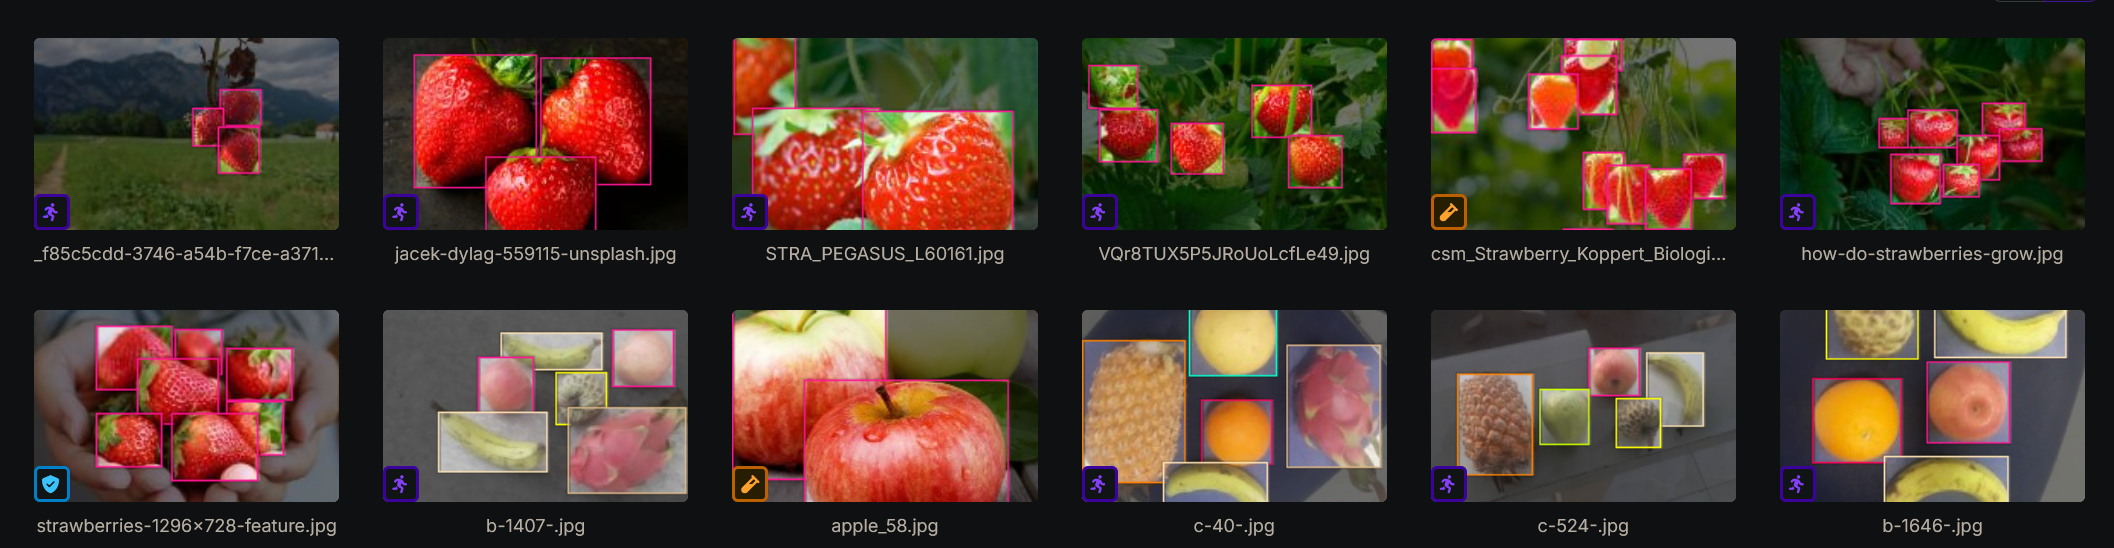  
Сделал следующие аугментации  
 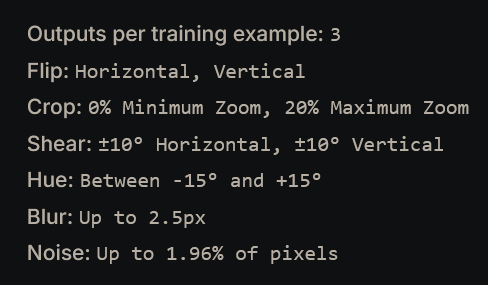

Проверим, что нынешняя модель не умеет определять клубнику


0: 640x544 1 apple, 1 orange, 52.2ms
Speed: 2.1ms preprocess, 52.2ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 544)


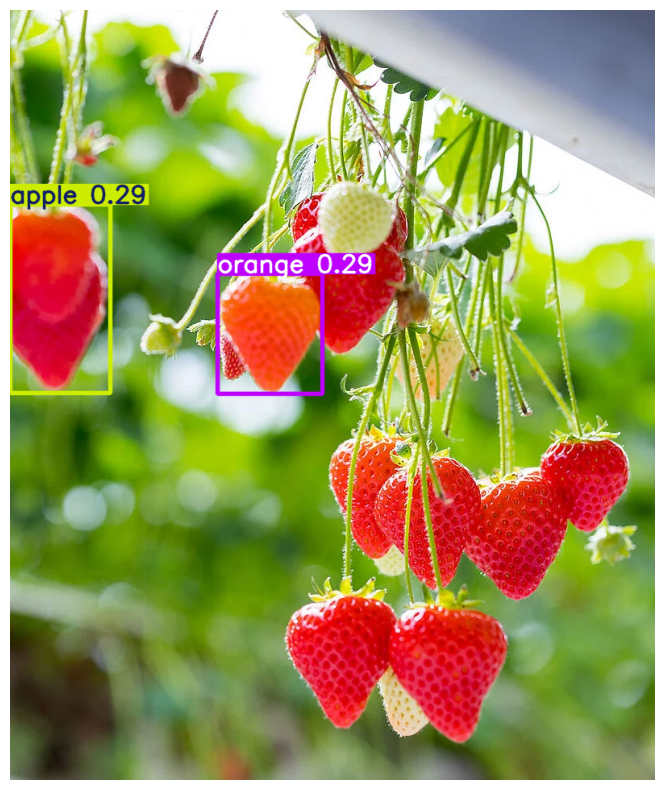

In [5]:
predict_and_show("images/csm_Strawberry_Koppert_Biological_Systems-8_fdb3c250f0.jpg")

Загружаем данные из проекта Roboflow

In [6]:
from roboflow import Roboflow
rf = Roboflow(api_key="PpvoOyN1jy4MtOEoWCFm")
project = rf.workspace("bafpersonal").project("fruit-detector-nt7fi-jk3sv")
version = project.version(1)
dataset = version.download("yolov12")
                

loading Roboflow workspace...
loading Roboflow project...


Дообучаем модель

In [7]:
import os
import glob
from ultralytics import YOLO
import csv
import matplotlib.pyplot as plt 

# Путь к папке с данными
DATA_DIR = r"C:\\Users\\leous\\.vscode\\computer_vision\\Практика 4\\fruit-detector-1"
DATA_YAML = os.path.join(DATA_DIR, "data.yaml")

# Директория для чекпоинтов
CKPT_DIR = os.path.join(os.getcwd(), "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

# Ищем последний чекпоинт для продолжения
all_ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "*.pt")), key=os.path.getctime)
resume_ckpt = all_ckpts[-1] if all_ckpts else None
print("Resume from:", resume_ckpt)

# Создаём кастомный callback
def custom_batch_callback(trainer):
    if hasattr(trainer, 'batch_i') and trainer.batch_i is not None:
        batch_idx = trainer.batch_i + trainer.epoch * len(trainer.train_loader)
        if batch_idx > 0 and batch_idx % 5 == 0:
            fname = f"ckpt_step{batch_idx}.pt"
            path = os.path.join(CKPT_DIR, fname)
            print(f"Saving checkpoint: {path}")
            trainer.model.save(path)
            ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "*.pt")), key=os.path.getctime)
            if len(ckpts) > 5:
                for obsolete in ckpts[:-5]:
                    os.remove(obsolete)

model = YOLO('yolov8n.pt')  # Пример инициализации модели
model.add_callback('on_train_batch_end', custom_batch_callback)

# Обучение модели с сохранением результатов
results = model.train(
    data=DATA_YAML,
    epochs=25,
    imgsz=640,
    batch=16,
    workers=4,
    resume=resume_ckpt
)

# Построение графика precision
try:
    # Чтение результатов из CSV-файла
    results_csv = os.path.join(results.save_dir, 'results.csv')
    
    if os.path.exists(results_csv):
        # Чтение данных
        epochs = []
        precisions = []
        with open(results_csv, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                if 'metrics/precision(B)' in row:
                    epochs.append(int(row['epoch']))
                    precisions.append(float(row['metrics/precision(B)']))
        
        # Построение графика
        plt.figure(figsize=(10, 5))
        plt.plot(epochs, precisions, marker='o', linestyle='-', color='b')
        plt.xlabel('Эпоха')
        plt.ylabel('Precision')
        plt.title('Метрика Precision на валидационных данных')
        plt.grid(True)
        
        # Сохранение графика
        plot_path = os.path.join(CKPT_DIR, 'validation_precision.png')
        plt.savefig(plot_path)
        plt.close()
        print(f"\nГрафик precision сохранён: {plot_path}")
    else:
        print("\nФайл с результатами не найден")

except Exception as e:
    print(f"\nОшибка при построении графика: {e}")

Resume from: None
New https://pypi.org/project/ultralytics/8.3.123 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.122  Python-3.10.11 torch-2.6.0.dev20241112+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=C:\\Users\\leous\\.vscode\\computer_vision\\ 4\\fruit-detector-1\data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=None, name=train29, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=None, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnos

train: Scanning C:\Users\leous\.vscode\computer_vision\Практика 4\fruit-detector-1\train\labels.cache... 8520 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8520/8520 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.20.1 ms, read: 85.819.8 MB/s, size: 32.3 KB)


val: Scanning C:\Users\leous\.vscode\computer_vision\Практика 4\fruit-detector-1\valid\labels.cache... 362 images, 0 backgrounds, 0 corrupt: 100%|██████████| 362/362 [00:00<?, ?it/s]


Plotting labels to c:\Users\leous\.vscode\computer_vision\runs\detect\train29\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.0005, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to c:\Users\leous\.vscode\computer_vision\runs\detect\train29
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      25/25      2.13G     0.5555     0.2854     0.9501         33        640: 100%|██████████| 533/533 [01:47<00:00,  4.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.95it/s]

                   all        362       1285      0.942      0.951      0.977      0.791



25 epochs completed in 0.783 hours.
Optimizer stripped from c:\Users\leous\.vscode\computer_vision\runs\detect\train29\weights\last.pt, 6.3MB
Optimizer stripped from c:\Users\leous\.vscode\computer_vision\runs\detect\train29\weights\best.pt, 6.3MB

Validating c:\Users\leous\.vscode\computer_vision\runs\detect\train29\weights\best.pt...
Ultralytics 8.3.122  Python-3.10.11 torch-2.6.0.dev20241112+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,008,768 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:03<00:00,  3.06it/s]


                   all        362       1285       0.95      0.955      0.982      0.797
          Bitter melon         15         22      0.947      0.955      0.969      0.561
               Brinjal          6         10      0.962          1      0.995       0.73
           Green Chili         21         36      0.902       0.75      0.886      0.477
                  Kiwi          4          4      0.903          1      0.995      0.995
           Lady finger         20         36      0.894      0.972      0.984      0.619
                 apple        113        158      0.963      0.986      0.992      0.894
                banana        210        298      0.964      0.977      0.993      0.851
              cucumber          5          7      0.954          1      0.995      0.769
          dragon fruit        145        146      0.994      0.993      0.995      0.875
                 guava        123        145      0.986      0.959      0.988      0.924
                orang

График Precision  
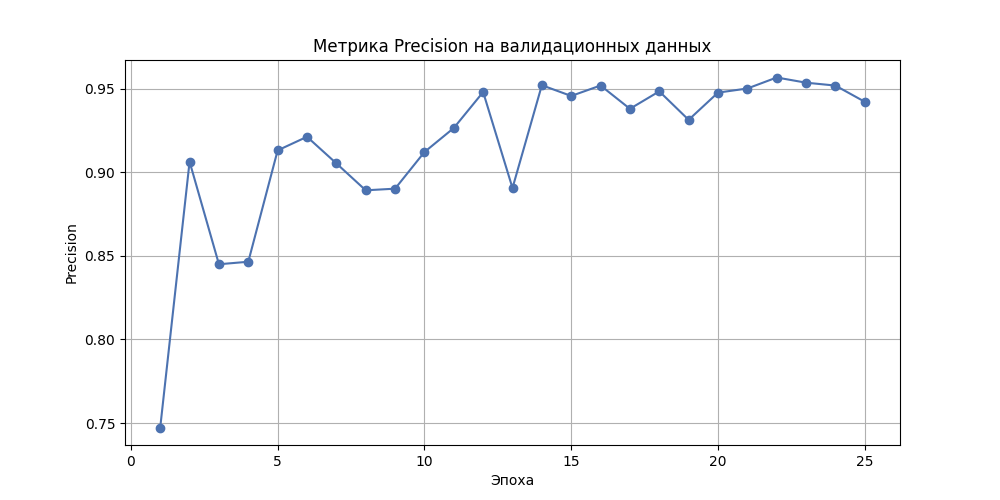

In [8]:
model.save("yolo_model.pt")


0: 640x640 5 strawberrys, 9.0ms
Speed: 3.4ms preprocess, 9.0ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


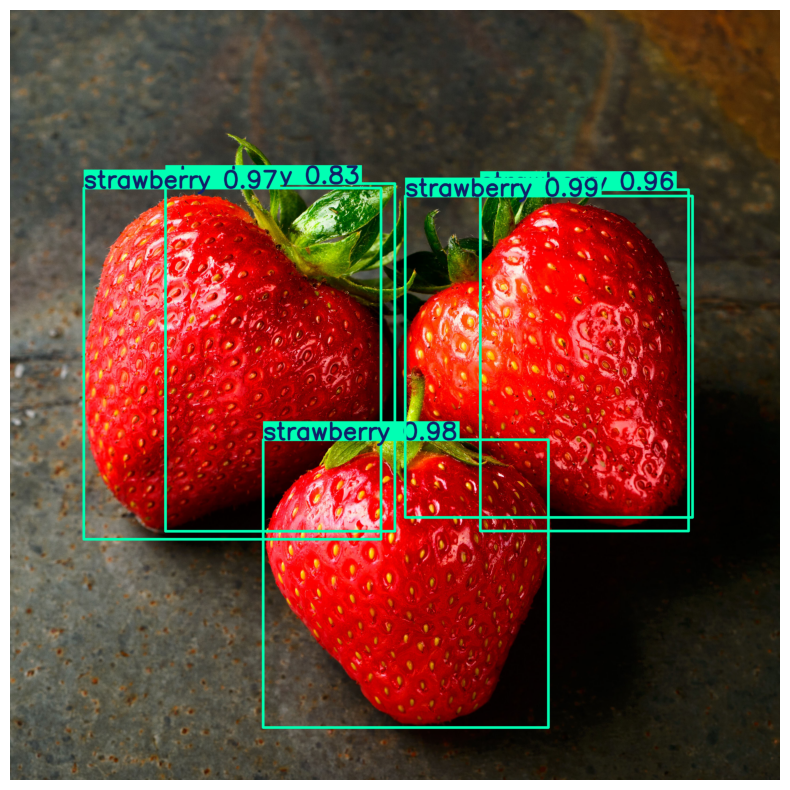


0: 384x640 8 strawberrys, 53.6ms
Speed: 1.3ms preprocess, 53.6ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


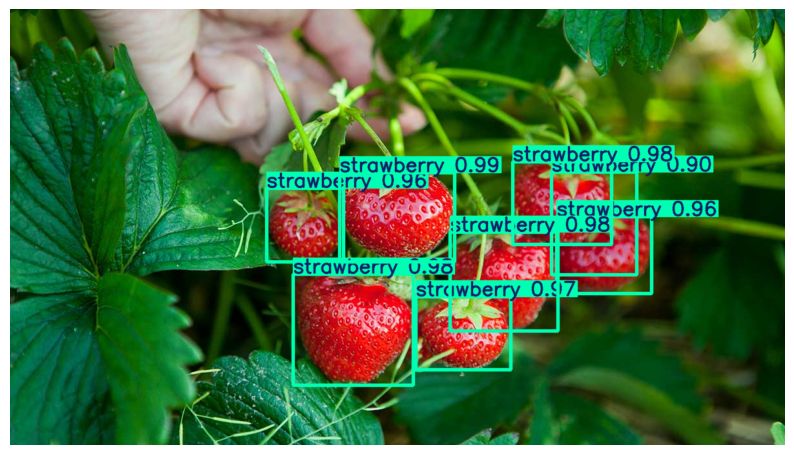


0: 640x640 1 banana, 1 dragon fruit, 1 pear, 1 pineapple, 8.8ms
Speed: 1.2ms preprocess, 8.8ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)


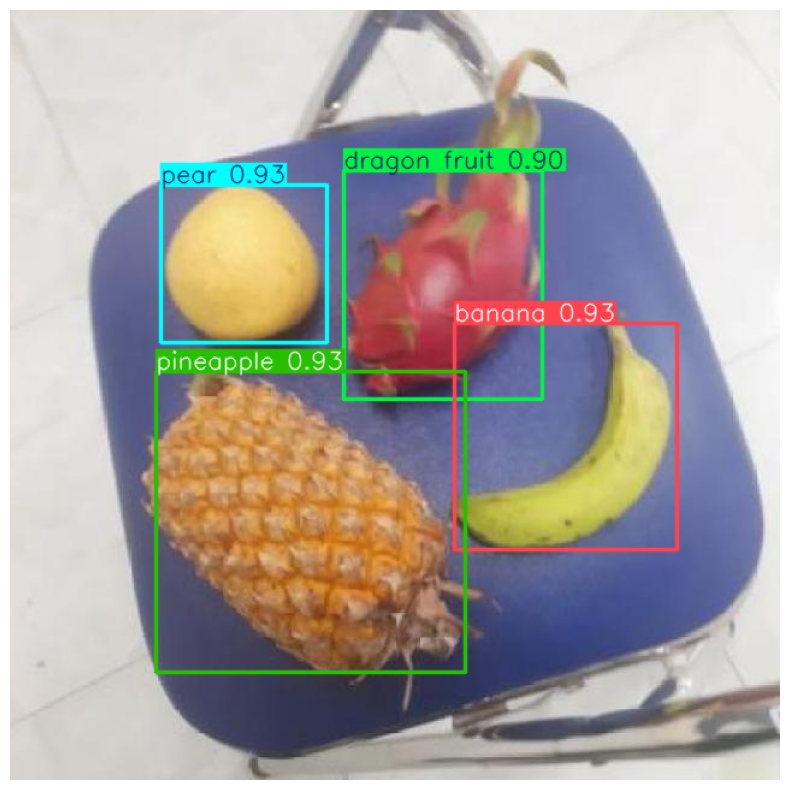


0: 640x640 1 apple, 2 bananas, 1 orange, 8.5ms
Speed: 1.4ms preprocess, 8.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


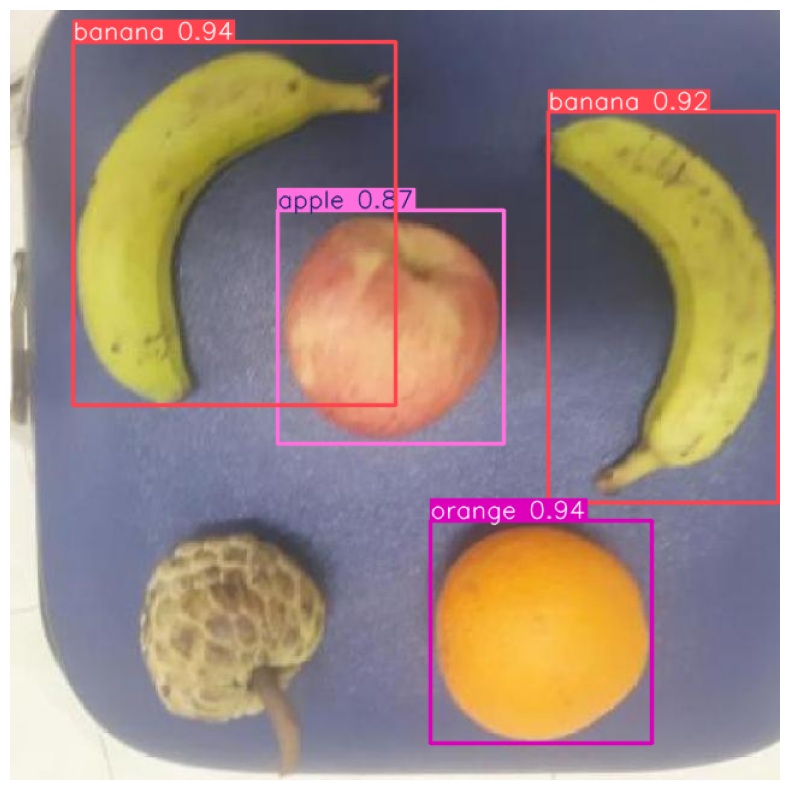


0: 640x640 2 apples, 2 bananas, 1 dragon fruit, 8.6ms
Speed: 1.1ms preprocess, 8.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


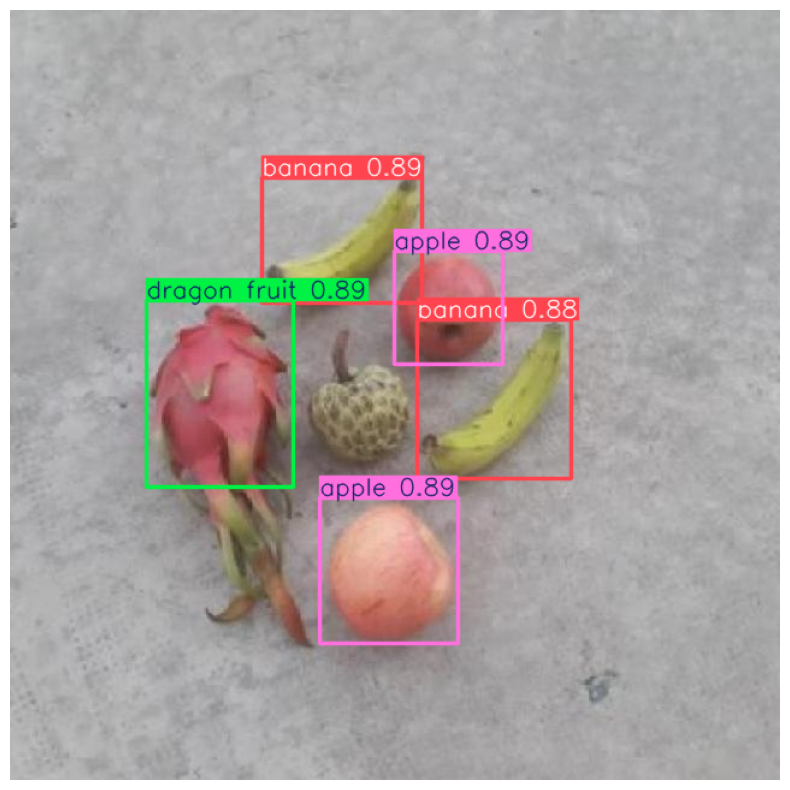

In [9]:
import random

def get_random_file_path(folder_path):
    # Получаем список всех файлов в папке
    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    if not files:
        raise FileNotFoundError(f"В папке {folder_path} нет файлов.")
    # Выбираем случайный файл
    random_file = random.choice(files)
    # Возвращаем полный путь
    return os.path.join(folder_path, random_file)

# predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/object-detection-1/valid/images"))
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"), "yolo_model.pt")
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"), "yolo_model.pt")
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/fruit-detector-1/valid/images"), "yolo_model.pt")
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/fruit-detector-1/valid/images"), "yolo_model.pt")
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/fruit-detector-1/valid/images"), "yolo_model.pt")

Как можно увидеть, модель начала распознавать все фрукты и клубнику в том числе